In [ ]:
"""
The mechanics of learning

http://galileoandeinstein.physics.virginia.edu/1995/lectures/morekepl.html
https://en.wikipedia.org/wiki/Kepler%27s_laws_of_planetary_motion

To sum things up, over those six years, Kepler
1 Got lots of good data from his friend Brahe (not without some struggle).
2 Tried to visualize the heck out of that data because he felt that something fishy
was going on.
3 Chose the simplest possible model that had a chance to fit the data (an ellipse).
4 Split the data so that he could work on part of it and keep an independent set
for validation.
5 Started with a tentative eccentricity and size, and iterated until the model fit the
observations.
6 Validated his model on the independent observations.
7 Looked back in disbelief.


The history of science is constructed on these seven steps, and as scientists have
learned over the centuries, deviating from them is a recipe for disaster.
https://plus.maths.org/content/origins-proof-ii-keplers-proofs

These steps are exactly what you’ll follow to learn something from data. Here,
there’s virtually no difference between saying that you’ll fit the data and saying that
you’ll make an algorithm learn from data. The process always involves a function with
unknown parameters whose values are estimated from data—in short, a model.

This chapter is about how to automate this generic function-fitting, which is all you
do with deep learning, deep neural networks being the generic functions, and
PyTorch makes this process as simple and transparent as possible. To make sure that
you get the key concepts right and to allow you to understand the mechanics of learning
algorithms from first principles, we’ll start with a model that’s a lot simpler than a
deep neural network.

Learning is parameter estimation
In this section, you learn how you can take data, choose a model, and estimate the
parameters of the model so that it gives good predictions on new data. To do so, you’ll
leave the intricacies of planetary motion and divert your attention to the second-hardest
problem in physics: calibrating instruments.
Figure 4.2 shows a high-level overview of what you’ll have implemented by the end
of the chapter. Given input data and the corresponding desired outputs (ground
truth), as well as initial values for the weights, the model is fed input data (forward
pass), and a measure of the error is evaluated by comparing the resulting outputs with
the ground truth. To optimize the parameter of the model, its weights—the change in
the error following a unit change in weights (the gradient of the error with respect to
the parameters)—is computed by using the chain rule for the derivative of a composite
function (backward pass). Then the value of the weights is updated in the direction
that leads to a decrease in the error. The procedure is repeated until the error,
evaluated on unseen data, falls below an acceptable level.
If this sounds obscure, we’ve got a whole chapter to clarify things. By the time
we’re done, all the pieces will fall into place, and the preceding paragraph will make
perfect sense to you.
Next, you take a problem with a noisy data set, build a model, and implement a
learning algorithm for it. You’ll start by doing everything by hand, but by the end of
the chapter, you’ll be letting PyTorch do all the heavy lifting. By the end of the chapter,
we’ll have covered many of the essential concepts that underlie training deep neural
networks, even if the motivating example is simple and the model isn’t a neural
network (yet!).

A hot problem
Suppose that you took a trip to some obscure location and brought back a fancy, wallmounted
analog thermometer. It looks great, it’s a perfect fit for your living room. Its
only flaw is that it doesn’t show units. Not to worry; you’ve got a plan. You’ll build a data
set of readings and corresponding temperature values in your favorite units, choose a
model, and adjust its weights iteratively until a measure of the error is low enough, and
you’ll finally be able to interpret the new readings in units you understand.
Start by making a note of temperature data in good old Celsius5 and measurements
from your new thermometer.

"""

In [1]:
%matplotlib inline
import numpy as np
import torch

t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c)      # temperature in Celcius
t_u = torch.tensor(t_u)      # unknown units
      
# t_c
# t_u

In [ ]:
"""
t_c are temperatures in Celsius, and t_u are the unknown units. You can expect noise
in both measurements coming from the devices themselves and from your approximate
readings. For convenience, the data is already in tensors, which you’ll use soon.


4.1.2 Choosing a linear model as a first try
In the absence of further knowledge, assume the simplest possible model for converting
between the two sets of measurements, as Kepler might have done. The two sets
may be linearly related. That is, multiplying t_u by a factor and adding a constant, you
may get the temperature in Celsius:
t_c = w * t_u + b

Is this assumption reasonable? Probably; you’ll see how well the final model performs.
(You chose to name w and b after weight and bias, two common terms for linear scaling
and the additive constant, which you’ll bump into all the time.)

NOTE Spoiler alert: We know that a linear model is correct because the problem
and data have been fabricated, but please bear with us; this model is a
useful motivating example to build your understanding of what PyTorch is
doing under the hood.

Now you need to estimate w and b, the parameters in the model, based on the data
you have. You must do this so that the temperatures you obtain from running the
unknown temperatures t_u through the model are close to temperatures you measured
in Celsius. If that process sounds like fitting a line through a set of measurements,
that’s exactly what you’re doing. As you go through this simple example
using PyTorch, realize that training a neural network essentially involves changing
the model for a slightly more elaborate one with a few (or a metric ton) more
parameters.

To flesh out the example again, you have a model with some unknown parameters,
and you need to estimate those parameters so that the error between predicted outputs
and measured values is as low as possible. You notice that you still need to define
a measure of such error. Such measure, which we refer to as the loss function, should
be high if the error is high and should ideally be as low as possible for a perfect match.
Your optimization process, therefore, should aim at finding w and b so that the loss
function is at a minimum level.

4.1.3 Less loss is what you want
A loss function (or cost function) is a function that computes a single numerical value
that the learning process attempts to minimize. The calculation of loss typically
involves taking the difference between the desired outputs for some training samples
and those produced by the model when fed those samples—in this case, the difference
between the predicted temperatures t_p output by the model and the actual
measurements, so t_p - t_c.
You need to make sure the loss function makes the loss positive both when t_p is
above and when below the true t_c, because the goal is to minimize this value. (Being
able to push the loss infinitely negative isn’t useful.) You have a few choices, the most
straightforward being |t_p - t_c| and (t_p - t_c)^2. Based on the mathematical
expression you choose, you can emphasize or discount certain errors. Conceptually, a loss
function is a way of prioritizing which errors to fix from your training samples, so that
your parameter updates result in adjustments to the outputs for the highly weighted samples
instead of changes to some other samples’ output that had a smaller loss.
Both of the example loss functions have a clear minimum in zero and grow monotonically
as the predicted value moves farther from the true value in either direction.
For this reason, both functions are said to be convex. Because your model is linear, the
loss as a function of w and b is also convex. Cases in which the loss is a convex function
of the model parameters are usually great to deal with because you can find a minimum
in an efficient way through specialized algorithms. Deep neural networks don’t
exhibit a convex loss, however, so those methods aren’t generally useful to you.

For the two loss functions |t_p - t_c| and (t_p - t_c)^2, as shown in figure 4.3,
notice that the square of differences behaves more nicely around the minimum: the
derivative of the error-squared loss with respect to t_p is zero when t_p equals t_c.
The absolute value, on the contrary, has an undefined derivative right where you’d
like to converge. This issue is less important than it looks in practice, but stick to the
square of differences for the time being.

It’s worth noting that the square difference also penalizes wildly wrong results more
than the absolute difference. Often, having more slightly wrong results is better than
having a few wildly wrong ones, and the squared difference helps prioritize those
results as desired.

4.1.4 From problem to PyTorch
You’ve figured out the model and the loss function, so you’ve already got a good part
of the high-level picture figured out. Now you need to set the learning process in
motion and feed it actual data. Also, enough with math notation already, so now
switch to PyTorch. After all, you came here for the fun.
You’ve already created your data tensors, so write out the model as a Python function
"""

In [95]:
def model(t_u, w, b):
    return w * t_u + b

In [ ]:
"""
in which you’re expecting t_u, w, and b to be the input tensor, weight parameter, and
bias parameter, respectively. In your model, the parameters will be PyTorch scalars
(aka zero-dimensional tensors), and the product operation will use broadcasting to
yield the returned tensors. Now define your loss:
"""

In [96]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()           # The loss is a mean square loss.


In [ ]:
"""
Note that you’re building a tensor of differences, taking their square elementwise and
finally producing a scalar loss function by averaging all elements in the resulting tensor.
The loss is a mean square loss.
Now you can initialize the parameters, invoke the model,
"""

In [97]:
w = torch.ones(())
b = torch.zeros(())

t_p = model(t_u, w, b)
t_p                 

tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000, 21.8000,
        48.4000, 60.4000, 68.4000])

In [ ]:
"""
and check the value of the loss:
"""

In [98]:
loss = loss_fn(t_p, t_c)
loss

tensor(1763.8848)

In [ ]:
"""
In this section, you implemented the model and the loss. The meat of the section is
how to estimate the w and b such that the loss reaches a minimum. First, you work
things out by hand; then you learn how to leverage PyTorch superpowers to solve the
same problem in a more general, off-the-shelf way.

4.1.5 Down along the gradient
In this section, you optimize the loss function with respect to the parameters by using
the so-called gradient descent algorithm and build your intuition about how gradient
descent works from first principles, which will help you a lot in the future. There are
ways to solve this particular example more efficiently, but those approaches aren’t
applicable to most deep learning tasks. Gradient descent is a simple idea that scales up
surprisingly well to large neural network models with millions of parameters.
Start with the mental image conveniently sketched out in figure 4.4. Suppose that
you’re in front of a machine sporting two knobs, labeled w and b. You’re allowed to
see the value of the loss on a screen and are told to minimize that value. Not knowing
the effect of the knobs on the loss, you’d probably start fiddling with them and
decide for each knob what direction makes the loss decrease. You’d probably decide
to rotate both knobs in their direction of decreasing loss. If you’re far from the optimal
value, you’re likely to see the loss decrease quickly and then slow as it gets closer
to the minimum. You’d notice that at some point, the loss climbs back up again, so
you’d invert the direction of rotation for one or both knobs. You’d also learn that
when the loss changes slowly, it’s a good idea to adjust the knobs more finely to avoid
reaching the point where the loss goes back up. After a while, eventually, you’d converge
to a minimum.

Gradient descent isn’t too different. The idea is to compute the rate of change of the
loss with respect to each parameter and apply a change to each parameter in the
direction of decreasing loss. As when you were fiddling with the knobs, you could estimate
such rate of change by applying a small change to w and b to see how much the
loss is changing in that neighborhood:
"""

In [99]:
delta = 0.1

loss_rate_of_change_w = \
    (loss_fn(model(t_u, w + delta, b), t_c) - 
     loss_fn(model(t_u, w - delta, b), t_c)) / (2.0 * delta)

# loss_rate_of_change_w

In [ ]:
"""
This code is saying that in a small neighborhood of the current values of w and b, a
unit increase in w leads to some change in the loss. If the change is negative, you need
to increase w to minimize the loss, whereas if the change is positive, you need to
decrease w. By how much? Applying a change to w that’s proportional to the rate of
change of the loss is a good idea, especially when the loss has several parameters:
you’d apply a change to those that exert a significant change on the loss. It’s also wise
to change the parameters slowly in general, because the rate of change could be dramatically
different at a distance from the neighborhood of the current w value. Therefore,
you should scale the rate of change by a typically small factor. This scaling factor
has many names; the one used in machine learning is learning_rate.

"""

In [100]:
learning_rate = 1e-2         # 1e+2 is the E notation version of the scientific notation 1 times 10 to the power of 2

w = w - learning_rate * loss_rate_of_change_w

# w                    # tensor([-44.1730])


In [ ]:
"""
You can do the same with b:
"""

In [101]:
loss_rate_of_change_b = \
    (loss_fn(model(t_u, w, b + delta), t_c) - 
     loss_fn(model(t_u, w, b - delta), t_c)) / (2.0 * delta)

b = b - learning_rate * loss_rate_of_change_b
# b

In [ ]:
"""
This code represents the basic parameter update step for gradient descent. By reiterating
these evaluations (provided that you choose a small-enough learning rate),
you’d converge to an optimal value of the parameters for which the loss computed on
the given data is minimal. We’ll show you the complete iterative process soon, but this
method of computing rates of change is rather crude and needs an upgrade. In the
next section, you see why and how.


4.1.6 Getting analytical
Computing the rate of change by using repeated evaluations of model and loss to
probe the behavior of the loss function in the neighborhood of w and b doesn’t scale
well to models with many parameters. Also, it isn’t always clear how large that neighborhood
should be. You chose delta equal to 0.1 earlier, but everything depends on
the shape of the loss as a function of w and b. If the loss changes too quickly compared
with delta, you won’t have a good idea of where downhill is.
What if you could make the neighborhood infinitesimally small, as in figure 4.5?
That’s exactly what happens when you take the derivative of the loss with respect to a
parameter analytically. In a model with two or more parameters, you compute the
individual derivatives of the loss with respect to each parameter and put them in a vector
of derivatives: the gradient.


To compute the derivative of the loss with respect to a parameter, you can apply the
chain rule and compute the derivative of the loss with respect to its input (which is the
output of the model) times the derivative of the model with respect to the parameter:
d loss_fn / d w = (d loss_fn / d t_p) * (d t_p / d w)

Recall that the model is a linear function and the loss is a sum of squares. Now figure
out the expressions for the derivatives. Recalling the expression for the loss
"""

In [ ]:
"""
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c) **2
    return squared_diffs.mean()
    
and remembering that d x^2 / d x = 2 x, you get
"""

In [103]:
def dloss_fn(t_p, t_c):
    # dsq_diffs = 2 * (t_p - t_c) 
    dsq_diffs = 2 * (t_p - t_c)  / t_p.size(0)
    return dsq_diffs

In [ ]:
"""
As for the model, recalling that the model is
# In[3]:
def model(t_u, w, b):
return w * t_u + b
you get derivatives of

"""

In [104]:
def dmodel_dw(t_u, w, b):
    return t_u


In [105]:
def dmodel_db(t_u, w, b):
    return 1.0

In [ ]:
"""
Putting all this together, the function that returns the gradient of the loss with respect
to w and b is:


def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dw = dloss_fn(t_p, t_c) * dmodel_dw(t_u, w, b)
    dloss_db = dloss_fn(t_p, t_c) * dmodel_db(t_u, w, b)
    return torch.stack([dloss_dw.mean(), dloss_db.mean()])
"""

In [106]:
def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dtp = dloss_fn(t_p, t_c)
    dloss_dw = dloss_dtp * dmodel_dw(t_u, w, b)
    dloss_db = dloss_dtp * dmodel_db(t_u, w, b)
    return torch.stack([dloss_dw.sum(), dloss_db.sum()])  # <1>

In [ ]:
"""
The same idea expressed in mathematical notation is shown in figure 4.6.
Again, you’re averaging (summing and dividing by a constant) over all data points
to get a single scalar quantity for each partial derivative of the loss.


4.1.7 The training loop
Now you have everything in place to optimize your parameters. Starting from a tentative
value for a parameter, you can iteratively apply updates to it for a fixed number of
iterations or until w and b stop changing. You can use several stopping criteria, but
stick to a fixed number of iterations for now.
While we’re at it, we’ll introduce you to another piece of terminology. A training
iteration during which you update the parameters for all your training samples is
called an epoch.
The complete training loop looks like this:
"""

In [114]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        w, b = params

        t_p = model(t_u, w, b)  # <1>
        loss = loss_fn(t_p, t_c)
        grad = grad_fn(t_u, t_c, t_p, w, b)  # <2>

        params = params - learning_rate * grad
       
        print('Epoch %d, Loss %f' % (epoch, float(loss))) # <3>
        # print(params)
            
    return params

In [ ]:
"""
The actual logging logic used for the output in this text is more complicated (see cell
15 in the same notebook),6 but the differences are unimportant for understanding
the core concepts in this chapter.

6 https://github.com/deep-learning-with-pytorch/dlwpt-code/blob/master/p1ch5/1_parameter_estimation.ipynb


Now invoke your training loop:

"""

In [113]:
training_loop(
    n_epochs = 100, 
    learning_rate = 1e-2, 
    params = torch.tensor([1.0, 0.0]), 
    t_u = t_u, 
    t_c = t_c)

Epoch 1, Loss 1763.884766
tensor([-44.1730,  -0.8260])
Epoch 2, Loss 5802484.500000
tensor([2568.4011,   45.1637])
Epoch 3, Loss 19408029696.000000
tensor([-148527.7344,   -2616.3931])
Epoch 4, Loss 64915905708032.000000
tensor([8589999.0000,  151310.8906])
Epoch 5, Loss 217130525461053440.000000
tensor([-4.9680e+08, -8.7510e+06])
Epoch 6, Loss 726257583152928129024.000000
tensor([2.8732e+10, 5.0610e+08])
Epoch 7, Loss 2429183416467662896627712.000000
tensor([-1.6617e+12, -2.9270e+10])
Epoch 8, Loss 8125122549611731432050262016.000000
tensor([9.6102e+13, 1.6928e+12])
Epoch 9, Loss 27176882120842590626938030653440.000000
tensor([-5.5580e+15, -9.7903e+13])
Epoch 10, Loss 90901105189019073810297959556841472.000000
tensor([3.2144e+17, 5.6621e+15])
Epoch 11, Loss inf
tensor([-1.8590e+19, -3.2746e+17])
Epoch 12, Loss inf
tensor([1.0752e+21, 1.8939e+19])
Epoch 13, Loss inf
tensor([-6.2181e+22, -1.0953e+21])
Epoch 14, Loss inf
tensor([3.5962e+24, 6.3346e+22])
Epoch 15, Loss inf
tensor([-2.0798

tensor([nan, nan])

In [ ]:
"""
Epoch 10, Loss 90901075478458130961171361977860096.000000
Params: tensor([3.2144e+17, 5.6621e+15])
Grad: tensor([-3.2700e+19, -5.7600e+17])
Epoch 11, Loss inf
Params: tensor([-1.8590e+19, -3.2746e+17])
Grad: tensor([1.8912e+21, 3.3313e+19])
tensor([-1.8590e+19, -3.2746e+17])

Wait—what happened? Your training process blew up, leading to losses becoming inf.
This result is a clear sign that params is receiving updates that are too large; their values
start oscillating back and forth as each update overshoots, and the next overcorrects
even more. The optimization process is unstable; it diverges instead of converging
to a minimum. You want to see smaller and smaller updates to params, not larger, as
shown in figure 4.7.


How can you limit the magnitude of the learning_rate * grad? Well, that process
looks easy. You could simply choose a smaller learning_rate. You usually change learning
rates by order of magnitude, so you might try 1e-3 or 1e-4, which would decrease
the magnitude of updates by orders of magnitude. Go with 1e-4 to see how it works out:

"""

In [115]:
training_loop(
    n_epochs = 100,
    learning_rate = 1e-4,
    params = torch.tensor([1.0, 0.0]),
    t_u = t_u,
    t_c = t_c)

Epoch 1, Loss 1763.884766
Epoch 2, Loss 323.090515
Epoch 3, Loss 78.929634
Epoch 4, Loss 37.552845
Epoch 5, Loss 30.540283
Epoch 6, Loss 29.351154
Epoch 7, Loss 29.148884
Epoch 8, Loss 29.113848
Epoch 9, Loss 29.107145
Epoch 10, Loss 29.105247
Epoch 11, Loss 29.104168
Epoch 12, Loss 29.103222
Epoch 13, Loss 29.102295
Epoch 14, Loss 29.101379
Epoch 15, Loss 29.100466
Epoch 16, Loss 29.099548
Epoch 17, Loss 29.098631
Epoch 18, Loss 29.097717
Epoch 19, Loss 29.096796
Epoch 20, Loss 29.095881
Epoch 21, Loss 29.094959
Epoch 22, Loss 29.094049
Epoch 23, Loss 29.093134
Epoch 24, Loss 29.092216
Epoch 25, Loss 29.091301
Epoch 26, Loss 29.090385
Epoch 27, Loss 29.089464
Epoch 28, Loss 29.088551
Epoch 29, Loss 29.087635
Epoch 30, Loss 29.086714
Epoch 31, Loss 29.085804
Epoch 32, Loss 29.084888
Epoch 33, Loss 29.083967
Epoch 34, Loss 29.083057
Epoch 35, Loss 29.082142
Epoch 36, Loss 29.081221
Epoch 37, Loss 29.080309
Epoch 38, Loss 29.079390
Epoch 39, Loss 29.078474
Epoch 40, Loss 29.077562
Epoch 

tensor([ 0.2327, -0.0438])

In [ ]:
"""
Nice. The behavior is stable now. But there’s another problem: updates to parameters
are small, so the loss decreases slowly and eventually stalls. You could obviate this issue
by making the learning_rate adaptive—that is, change according to the magnitude
of updates. You can use several optimization schemes for that purpose; you see one
toward the end of this chapter, in section “Optimizers a-la Carte”.
Another potential troublemaker exists in the update term: the gradient itself. Go
back to look at grad at epoch 1 during optimization. You see that the first-epoch gradient
for the weight is about 50 times larger than the gradient for the bias, so the weight
and bias live in differently scaled spaces. In this case, a learning rate that’s large
enough to meaningfully update one is so large that it’s unstable for the other, or a rate
that’s appropriate for the second one won’t be large enough to change the first meaningfully.
You’re not going to be able to update your parameters unless you change
your formulation of the problem. You could have individual learning rates for each
parameter, but for models with many parameters, this approach would be too much to
bother with; it’s babysitting of the kind you don’t like.
You have a simpler way to keep things in check: change the inputs so that the gradients
aren’t so different. You can make sure that the range of the input doesn’t get
too far from the range of -1.0 to 1.0, roughly speaking. In this case, you can achieve
something close enough to that example by multiplying t_u by 0.1:
"""

In [116]:
t_un = 0.1 * t_u

In [ ]:
"""
Here, you denote the normalized version of t_u by appending n to the variable name.
At this point, you can run the training loop on your normalized input:
"""

In [117]:
training_loop(
    n_epochs = 100,
    learning_rate = 1e-2,
    params = torch.tensor([1.0, 0.0]),
    t_u = t_un,            # You’ve updated t_u to your new, rescaled t_un.
    t_c = t_c)

Epoch 1, Loss 80.364342
Epoch 2, Loss 37.574913
Epoch 3, Loss 30.871077
Epoch 4, Loss 29.756193
Epoch 5, Loss 29.507153
Epoch 6, Loss 29.392456
Epoch 7, Loss 29.298828
Epoch 8, Loss 29.208717
Epoch 9, Loss 29.119415
Epoch 10, Loss 29.030489
Epoch 11, Loss 28.941877
Epoch 12, Loss 28.853565
Epoch 13, Loss 28.765553
Epoch 14, Loss 28.677851
Epoch 15, Loss 28.590431
Epoch 16, Loss 28.503319
Epoch 17, Loss 28.416498
Epoch 18, Loss 28.329973
Epoch 19, Loss 28.243742
Epoch 20, Loss 28.157804
Epoch 21, Loss 28.072151
Epoch 22, Loss 27.986797
Epoch 23, Loss 27.901728
Epoch 24, Loss 27.816950
Epoch 25, Loss 27.732464
Epoch 26, Loss 27.648256
Epoch 27, Loss 27.564344
Epoch 28, Loss 27.480707
Epoch 29, Loss 27.397362
Epoch 30, Loss 27.314295
Epoch 31, Loss 27.231512
Epoch 32, Loss 27.149010
Epoch 33, Loss 27.066790
Epoch 34, Loss 26.984844
Epoch 35, Loss 26.903175
Epoch 36, Loss 26.821791
Epoch 37, Loss 26.740679
Epoch 38, Loss 26.659838
Epoch 39, Loss 26.579279
Epoch 40, Loss 26.498987
Epoch 41,

tensor([ 2.7553, -2.5162])

In [ ]:
"""
Even though you set your learning rate back to 1e-2, parameters didn’t blow up
during iterative updates. Now take a look at the gradients; they were of similar magnitudes,
so using a single learning_rate for both parameters worked fine. You probably
could do a better job of normalization than rescaling by a factor of ten, but because
doing so is good enough for your needs, stick it for now.

NOTE The normalization here helps you get the network trained, but you
could make an argument that it’s not strictly needed to optimize the parameters
for this problem. That’s absolutely true! This problem is small enough
that you have numerous ways to beat the parameters into submission. For
larger, more sophisticated problems, however, normalization is an easy and
effective (if not crucial!) tool to use to improve model convergence.

Next, run the loop for enough iterations to see the changes in params get small.
Change n_epochs to 5000:
"""

In [119]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c,
                  print_params=True):
    for epoch in range(1, n_epochs + 1):
        w, b = params

        t_p = model(t_u, w, b)  # <1>
        loss = loss_fn(t_p, t_c)
        grad = grad_fn(t_u, t_c, t_p, w, b)  # <2>

        params = params - learning_rate * grad

        if epoch in {1, 2, 3, 10, 11, 99, 100, 4000, 5000}:  # <3>
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
            if print_params:
                print('    Params:', params)
                print('    Grad:  ', grad)
        if epoch in {4, 12, 101}:
            print('...')

        if not torch.isfinite(loss).all():
            break  # <3>
            
    return params

In [121]:
params = training_loop(
    n_epochs = 5000,
    learning_rate = 1e-2,
    params = torch.tensor([1.0, 0.0]),
    t_u = t_un,
    t_c = t_c,
    print_params = False
    )

params


Epoch 1, Loss 80.364342
Epoch 2, Loss 37.574913
Epoch 3, Loss 30.871077
...
Epoch 10, Loss 29.030489
Epoch 11, Loss 28.941877
...
Epoch 99, Loss 22.214186
Epoch 100, Loss 22.148710
...
Epoch 4000, Loss 2.927680
Epoch 5000, Loss 2.927648


tensor([  5.3671, -17.3012])

In [ ]:
"""
Epoch 1, Loss 80.364342
Epoch 2, Loss 37.574917
Epoch 3, Loss 30.871077
...
Epoch 10, Loss 29.030487
Epoch 11, Loss 28.941875
...
Epoch 99, Loss 22.214186
Epoch 100, Loss 22.148710
...
Epoch 4000, Loss 2.927680
Epoch 5000, Loss 2.927648
tensor([ 5.3671, -17.3012])

Good. You saw the loss decrease while you were changing parameters along the direction
of gradient descent. The loss didn’t go to zero, which could mean that iterations
weren’t enough to converge to zero or that the data points aren’t sitting on a line. As
anticipated, your measurements weren’t perfectly accurate or noise was involved in
the reading.

But look: the value for w and b looks an awful lot like the numbers you need to use
to convert Celsius to Fahrenheit (after accounting for the earlier normalization when
you multiplied your inputs by 0.1). The exact values are w=5.5556 and b=-17.7778.
Your fancy thermometer was showing temperatures in Fahrenheit the whole time,
which is no big discovery, but it proves that your gradient descent optimization process
works.

Next, do something that you should have done right from the start: plot your data.
We didn’t introduce this topic until now for the sake of drama (the surprise effect).
But seriously, the first thing that anyone doing data science should do is plot the heck
out of the data.

"""

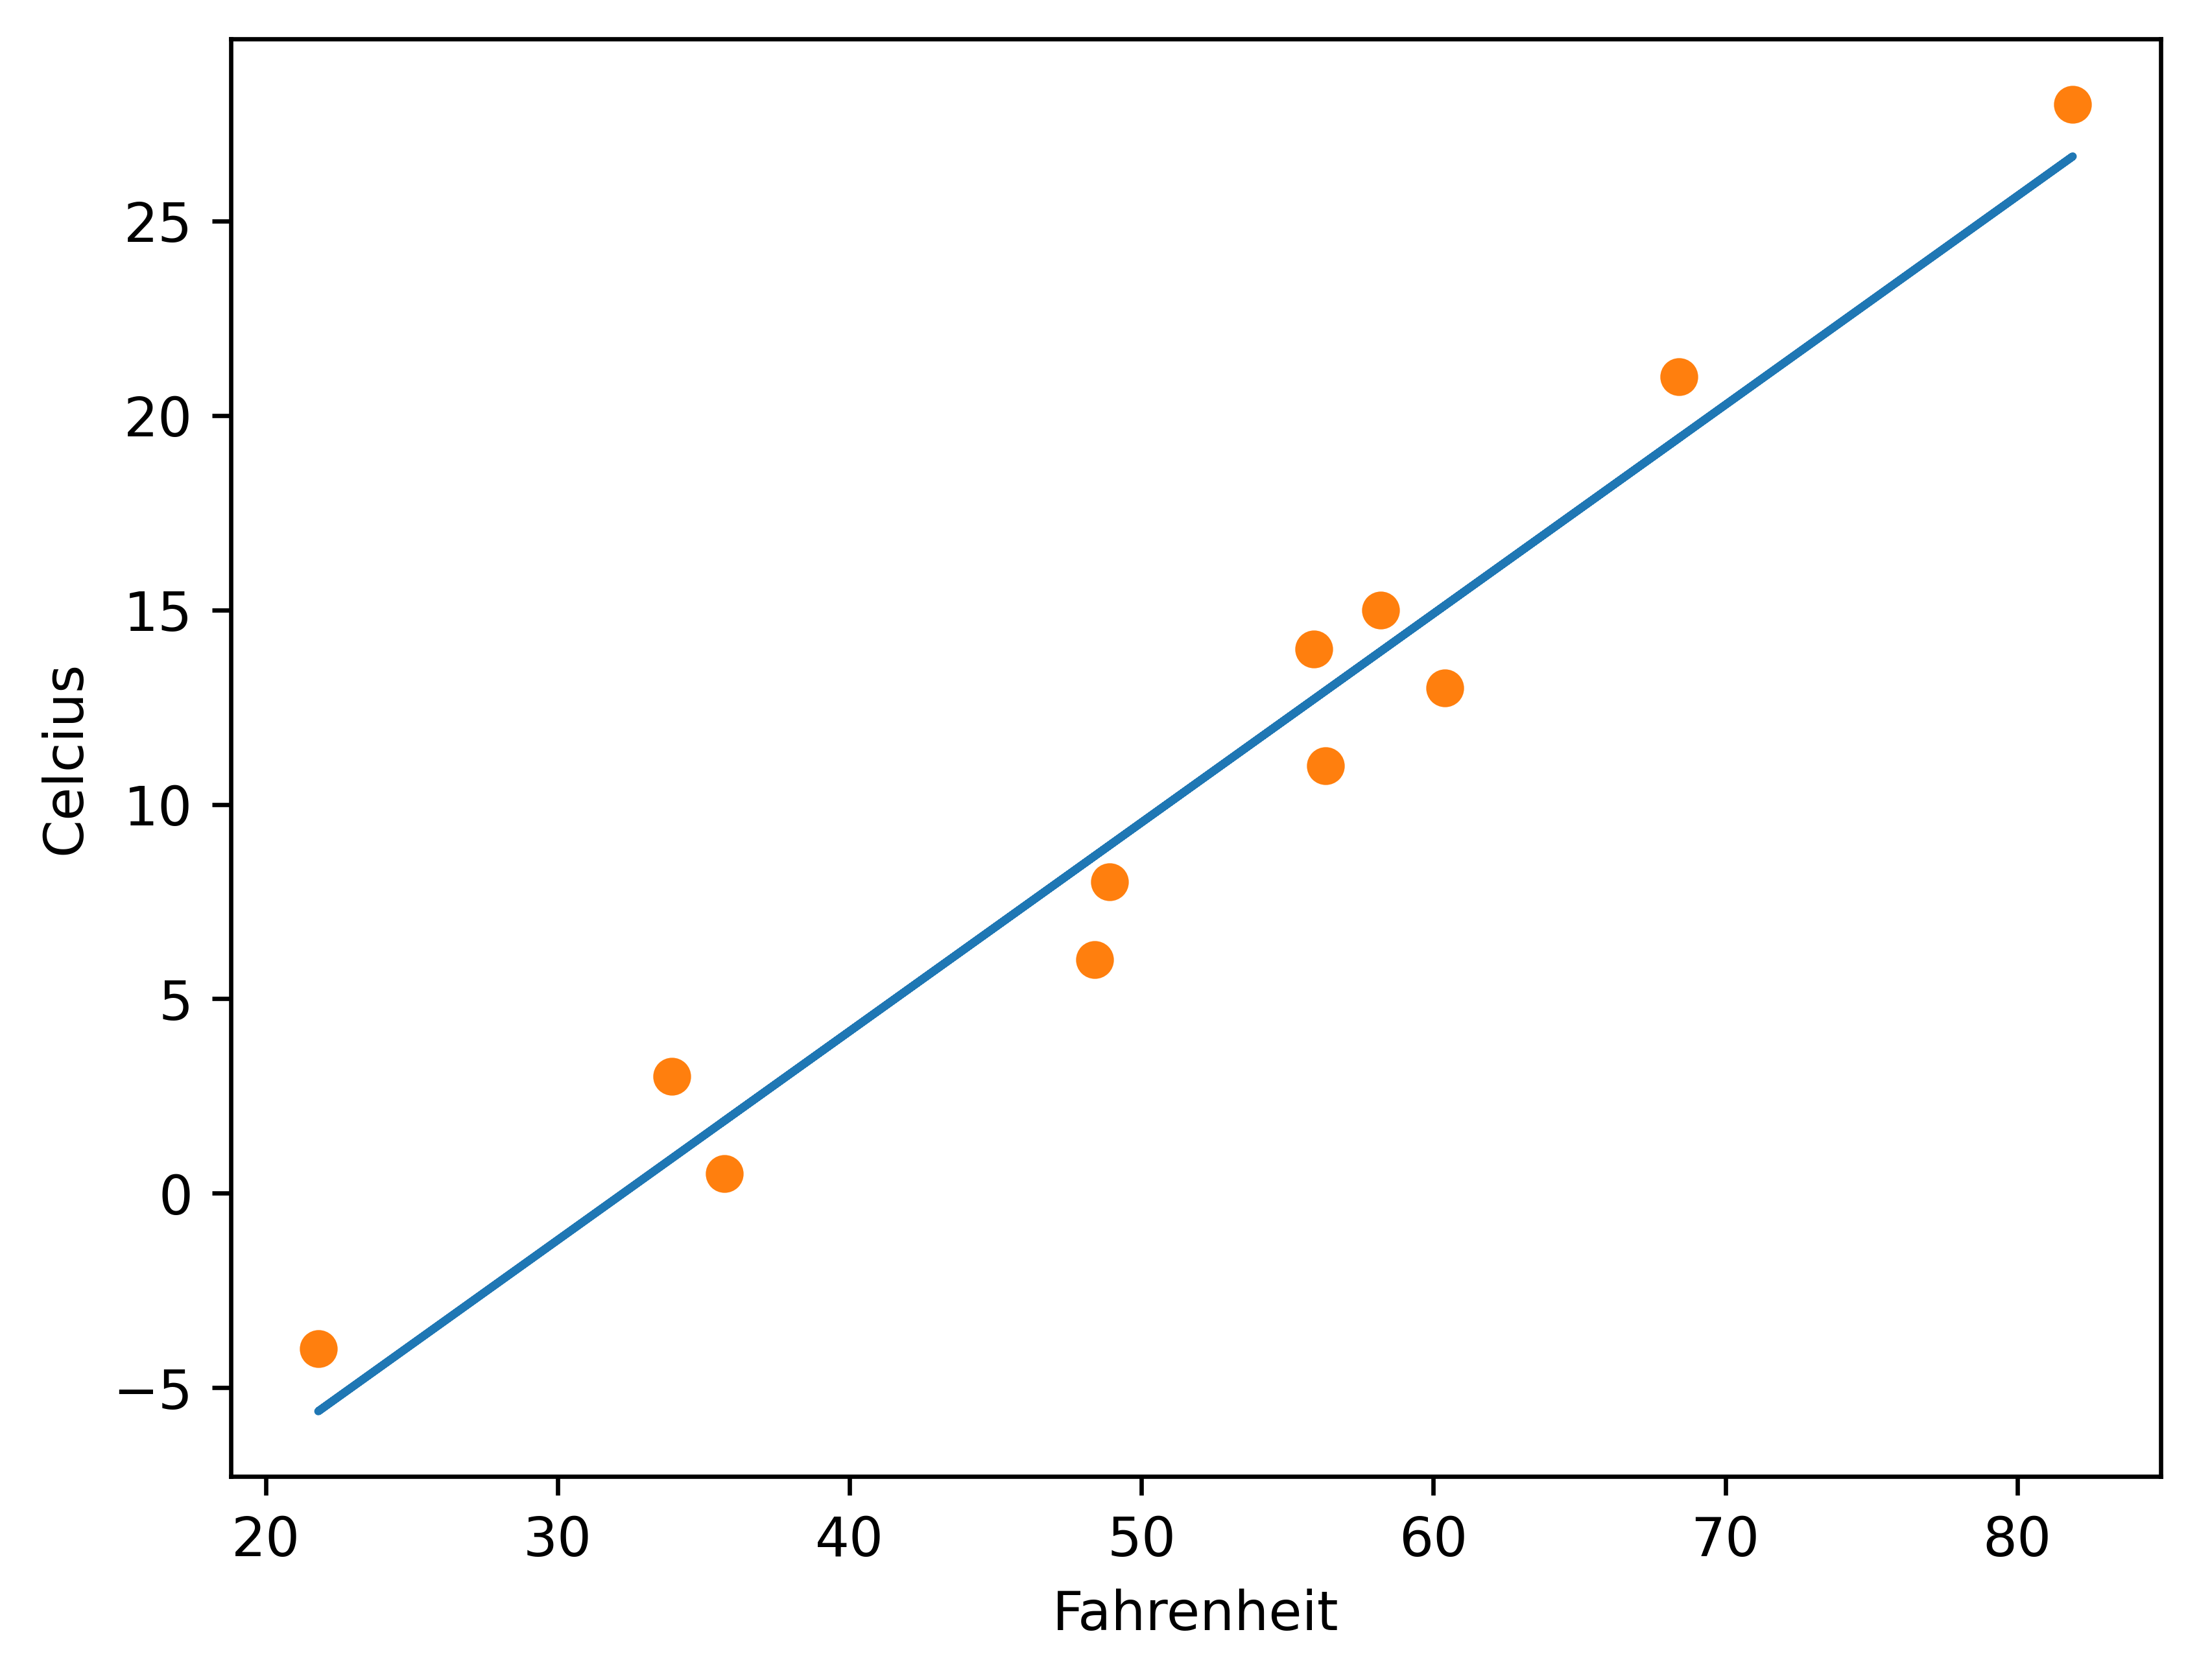

In [126]:
%matplotlib inline
from matplotlib import pyplot as plt

t_p = model(t_un, *params)

fig = plt.figure(dpi=600)
plt.xlabel("Fahrenheit")
plt.ylabel("Celcius")

plt.plot(t_u.numpy(), t_p.detach().numpy())  # But you’re plotting the raw unknown values
plt.plot(t_u.numpy(), t_c.numpy(), 'o')

# Testing without the numpy() function -- same output
# plt.plot(t_u, t_p)   
# plt.plot(t_u, t_c, 'o')

# This code produces Figure 4.8.

In [ ]:
"""
The linear model is a good model for the data, it seems. It also seems that your measurements
are somewhat erratic. You should either call your optometrist for a new
pair of glasses or think about returning your fancy thermometer.
"""

In [ ]:
"""
4.2 PyTorch’s autograd: Backpropagate all things

In your little adventure so far, you saw a simple example of backpropagation. You computed
the gradient of a composition of functions—the model and the loss—with
respect to their innermost parameters—w and b—by propagating derivatives backward
via the chain rule. The basic requirement is that all functions you’re dealing with are
differentiable analytically. In this case, you can compute the gradient (which we called
“the rate of change of the loss” earlier) with respect to the parameters in one sweep.
Should you have a complicated model with millions of parameters, as long as the
model is differentiable, computing the gradient the loss with respect to parameters
amounts to writing the analytical expression for the derivatives and evaluating them
once. Granted, writing the analytical expression for the derivatives of a deep composition
of linear and nonlinear functions isn’t a lot of fun.7 It isn’t particularly quick, either.

This situation is where PyTorch tensors come to the rescue, with a PyTorch component
called autograd. PyTorch tensors can remember where they come from in terms
of the operations and parent tensors that originated them, and they can provide the
chain of derivatives of such operations with respect to their inputs automatically. You
won’t need to derive your model by hand;8 given a forward expression, no matter how
nested, PyTorch provides the gradient of that expression with respect to its input
parameters automatically.
At this point, the best way to proceed is to rewrite the thermometer calibration
code, this time using autograd, and see what happens. First, recall your model and loss
function, as shown in the following listing.

Listing 4.2 code/p1ch5/2_autograd.ipynb
"""

In [7]:
%matplotlib inline
import numpy as np
import torch
torch.set_printoptions(edgeitems=2)

In [8]:
t_c = torch.tensor([0.5, 14.0, 15.0, 28.0, 11.0, 8.0,
                    3.0, -4.0, 6.0, 13.0, 21.0])
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9,
                    33.9, 21.8, 48.4, 60.4, 68.4])
t_un = 0.1 * t_u

In [9]:
def model(t_u, w, b):
    return w * t_u + b

In [10]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

In [ ]:
"""
Again initialize a parameters tensor:
"""

In [11]:
params = torch.tensor([1.0, 0.0], requires_grad=True)

In [ ]:
"""
Notice the requires_grad=True argument to the tensor constructor? That argument
is telling PyTorch to track the entire family tree of tensors resulting from operations
on params. In other words, any tensor that has params as an ancestor has access to the
chain of functions that were called to get from params to that tensor. In case these
functions are differentiable (and most PyTorch tensor operations are), the value of
the derivative is automatically populated as a grad attribute of the params tensor.
In general, all PyTorch tensors have an attribute named grad, normally None:

"""

In [12]:
params.grad is None

True

In [ ]:
"""
All you have to do to populate it is start with a tensor with requires_grad set to True,
call the model, compute the loss, and then call backward on the loss tensor:

"""

In [13]:
loss = loss_fn(model(t_u, *params), t_c)
loss.backward()
params.grad

tensor([4517.2969,   82.6000])

In [ ]:
"""
At this point, the grad attribute of params contains the derivatives of the loss with
respect to each element of params (figure 4.9).
Figure 4.9 The forward graph and backward graph of model as computed with autograd
You could have any number of tensors with requires_grad set to True and any
composition of functions. In this case, PyTorch would compute derivatives of the loss
throughout the chain of functions (the computation graph) and accumulate their values
in the grad attribute of those tensors (the leaf nodes of the graph).

Alert: Big gotcha ahead. This is one thing that PyTorch newcomers (and a lot of
more experienced folks) trip up on regularly. We wrote accumulate, not store.

WARNING Calling backward leads derivatives to accumulate at leaf nodes. You
need to zero the gradient explicitly after using it for parameter updates.

"""

In [ ]:
"""
To repeat, calling backward leads derivatives to accumulate at leaf nodes. So if backward
has been called earlier, the loss is evaluated again, and backward is called again
(as in any training loop), the gradient at each leaf is accumulated (summed) on top of
the one computed at the preceding iteration, which leads to an incorrect value for the
gradient.

To prevent this situation from occurring, you need to zero the gradient explicitly at
each iteration. You can do so easily by using the in-place zero_ method:


"""


In [14]:
if params.grad is not None:
    params.grad.zero_()

In [ ]:
"""
NOTE You may be curious why zeroing the gradient is a required step instead
of automatic whenever you call backward. The reason is to provide more flexibility
and control for working with gradients in complicated models.

Having this reminder drilled into your head, now see how your autograd-enabled
training code looks like, start to end:
"""

In [15]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        if params.grad is not None:
            params.grad.zero_()
        
        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)
        loss.backward()
        
        params = (params - learning_rate * params.grad).detach().requires_grad_()
        
        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
    return params

In [ ]:
"""
Notice that when you updated params, you also did an odd .detach().requires_
grad_() dance. To understand why, think about the computation graph that
you’ve built. Reformulate your params update line a little so that you’re not reusing variable
names: p1 = (p0 * lr * p0.grad) Here, p0 is the random weights with which you
initialized the model. p0.grad is computed from a combination of p0 and your training
data via the loss function.

So far, so good. Now you need to look at the second iteration of the loop: p2 = (p1
* lr * p1.grad). As you’ve seen, the computation graph for p1 goes back to p0,
which is problematic because (a) you have to keep p0 in memory (until you’re done
with training), and (b) it confuses the matter of where you should be assigning error
via backpropagation.

Instead, detach the new params tensor from the computation graph associated
with its update expression by calling .detatch(). This way, params effectively loses the
memory of the operations that generated it. Then you can reenable tracking by calling
.requires_grad_(), an in_place operation (see the trailing _) that reactivates
autograd for the tensor. Now you can release the memory held by old versions of
params and need to backpropagate through only your current weights.
See whether this code works:
"""

In [16]:
training_loop(
    n_epochs = 5000,
    learning_rate = 1e-2,
    params = torch.tensor([1.0, 0.0], requires_grad=True),
    t_u = t_un,
    t_c = t_c)

Epoch 500, Loss 7.860115
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957698
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927830
Epoch 4000, Loss 2.927679
Epoch 4500, Loss 2.927652
Epoch 5000, Loss 2.927647


tensor([  5.3671, -17.3012], requires_grad=True)

In [ ]:
"""
You get the same result that you got previously. Good for you! Although you’re capable
of computing derivatives by hand, you no longer need to.

"""

In [ ]:
"""
4.2.1 Optimizers a la carte
This code uses vanilla gradient descent for optimization, which works fine for this simple
case. Needless to say, several optimization strategies and tricks can help convergence,
especially when models get complicated.
Now is the right time to introduce the way that PyTorch abstracts the optimization
strategy away from user code, such as the training loop, sparing you from the boilerplate
busywork of having to update every parameter in your model yourself. The
torch module has an optim submodule where you can find classes that implement different
optimization algorithms. Here’s an abridged listing:
"""

In [18]:
import torch.optim as optim

In [19]:
dir(optim)

['ASGD',
 'Adadelta',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'NAdam',
 'Optimizer',
 'RAdam',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional',
 '_multi_tensor',
 'lr_scheduler',
 'swa_utils']

In [ ]:
"""
Every optimizer constructor takes a list of parameters (aka PyTorch tensors, typically
with requires_grad set to True) as the first input. All parameters passed to the optimizer
are retained inside the optimizer object so that the optimizer can update their
values and access their grad attribute, as represented in figure 4.10.

Each optimizer exposes two methods: zero_grad and step. The former zeros the
grad attribute of all the parameters passed to the optimizer upon construction. The
latter updates the value of those parameters according to the optimization strategy
implemented by the specific optimizer.

Now create params and instantiate a gradient descent optimizer:
"""

In [20]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-5
optimizer = optim.SGD([params], lr=learning_rate)

In [ ]:
"""
Here, SGD stands for Stochastic Gradient Descent. The optimizer itself is a vanilla gradient
descent (as long as the momentum argument is set to 0.0, which is the default). The
term stochastic comes from the fact that the gradient is typically obtained by averaging
over a random subset of all input samples, called a minibatch. The optimizer itself,
however, doesn’t know whether the loss was evaluated on all the samples (vanilla) or a
random subset thereof (stochastic), so the algorithm is the same in the two cases.

Anyway, take your fancy new optimizer for a spin:
"""

In [21]:
t_p = model(t_u, *params)
loss = loss_fn(t_p, t_c)
loss.backward()

optimizer.step()

params

tensor([ 9.5483e-01, -8.2600e-04], requires_grad=True)

In [ ]:
"""
The value of params was updated when step was called, and you didn’t have to touch
it yourself! What happened was that the optimizer looked into params.grad and
updated params by subtracting learning_rate times grad from it, exactly as in your
former hand-rolled code.

Are you ready to stick this code in a training loop? Nope! The big gotcha almost
got you: you forgot to zero out the gradients. Had you called the preceding code in a
loop, gradients would have accumulated in the leaves at every call to backward, and
your gradient descent would have been all over the place!
Here’s the loop-ready code, with the extra zero_grad in the right spot (before the
call to backward):

"""

In [23]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

t_p = model(t_un, *params)
loss = loss_fn(t_p, t_c)

optimizer.zero_grad()
loss.backward()
optimizer.step()

params

tensor([1.7761, 0.1064], requires_grad=True)

In [ ]:
"""
Perfect! See how the optim module helped you abstract away the specific optimization
scheme? All you have to do is provide a list of params to it (that list can be extremely
long, as needed for deep neural network models) and then forget about the details.

Update your training loop accordingly:

"""

In [24]:
def training_loop(n_epochs, optimizer, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if  epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
    
    return params

In [25]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

training_loop(
        n_epochs = 5000,
        optimizer = optimizer,
        params = params,
        t_u = t_un,          # updated input
        t_c = t_c
        )


Epoch 500, Loss 7.860115
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957698
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927830
Epoch 4000, Loss 2.927679
Epoch 4500, Loss 2.927652
Epoch 5000, Loss 2.927647


tensor([  5.3671, -17.3012], requires_grad=True)

In [ ]:
"""
Again, you get the same result as before. Great. You have further confirmation that
you know how to descend a gradient by hand! To test more optimizers, all you have to
do is instantiate a different optimizer, such as Adam, instead of SGD. The rest of the
code stays as is. This stuff is pretty handy.

We won’t go into much detail on Adam, but it suffices to say that it’s a more sophisticated
optimizer in which the learning rate is set adaptively. In addition, it’s a lot less
sensitive to the scaling of the parameters—so insensitive that you can go back to use
the original (non-normalized) input t_u and even increase the learning rate to 1e-1.

Adam won’t even blink:

"""

In [26]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-1
optimizer = optim.Adam([params], lr=learning_rate)

training_loop(
        n_epochs = 2000,
        optimizer = optimizer,
        params = params,
        t_u = t_u,     # Note that you’re back to the original t_u as input.
        t_c = t_c
        )

Epoch 500, Loss 7.612900
Epoch 1000, Loss 3.086700
Epoch 1500, Loss 2.928579
Epoch 2000, Loss 2.927644


tensor([  0.5367, -17.3021], requires_grad=True)

In [ ]:
"""
The optimizer isn’t the only flexible part of your training loop. Turn your attention to
the model. To train a neural network on the same data and the same loss, all you’d
need to change is the model function. Doing this wouldn’t make sense in this case,
because you know that converting Celsius to Fahrenheit amounts to a linear transformation.
Neural networks allow you to remove your arbitrary assumptions about the
shape of the function you should be approximating. Even so, neural networks manage
to be trained even when the underlying processes are highly nonlinear (such in the
case of describing an image with a sentence).

We’ve touched on a lot of the essential concepts that will enable you to train complicated
deep learning models while knowing what’s going on under the hood: backpropagation
to estimate gradients, autograd, and optimizing weights of models by
using gradient descent or other optimizers. We don’t have a whole lot more to cover.
The rest is mostly filling in the blanks, however extensive they are.
Next, we discuss how to split up samples, which sets up a perfect use case for learning
to control autograd better.

"""

In [ ]:
"""
4.2.2 Training, validation, and overfitting
Johannes Kepler kept a part of the data on the side so that he could validate his models
on independent observations—a vital thing to do, especially when the model you
adopt could potentially approximate functions of any shape, as in the case of neural
networks. In other words, a highly adaptable model tends to use its many parameters
to make sure that the loss is minimal at the data points, but you’ll have no guarantee
that the model behaves well away from or between the data points. After all, that’s all
you’re asking the optimizer to do: minimize the loss at the data points. Sure enough,
if you had independent data points that you didn’t use to evaluate your loss or
descend along its negative gradient, you’d soon find out that evaluating the loss at
those independent data points would yield a higher-than-expected loss. We’ve already
mentioned this phenomenon, called overfitting.

The first action you can take to combat overfitting is to recognize that it might
happen. To do so, as Kepler figured out in 1600, you must take a few data points out
of your data set (the validation set) and fit our model to the remaining data points (the
training set), as shown in figure 4.11. Then, while you’re fitting the model, you can
evaluate the loss once on the training set and once on the validation set. When you’re
trying to decide whether you’ve done a good job of fitting your model to the data, you
must look at each data set!

The first figure, the training loss, tells you whether your model can fit the training
set at all—in other words, whether your model has enough capacity to process the relevant
information in the data. If your mysterious thermometer somehow managed to
measure temperatures by using a logarithmic scale, your poor linear model wouldn’t
have had a chance to fit those measurements and provide a sensible conversion to Celsius.
In that case, your training loss (the loss you were printing in the training loop)
would stop decreasing well before approaching zero.

A deep neural network can potentially approximate complicated functions, provided
that the number of neurons—and, therefore, parameters—is high enough. The
fewer the parameters, the simpler the shape of the function your network will be able
to approximate. So here’s rule one: if the training loss isn’t decreasing, chances are
that the model is too simple for the data. The other possibility is that your data doesn’t
contain meaningful information for it to explain the output. If the nice folks at the
shop sold you a barometer instead of a thermometer, you’d have little chance to predict
temperature in Celsius from pressure alone, even if you used the latest neural network
architecture from Quebec.9

What about the validation set? Well, if the loss evaluated in the validation set
doesn’t decrease along with the training set, your model is improving its fit of the samples
it’s seeing during training, but it isn’t generalizing to samples outside this precise
set. As soon as you evaluate the model at new, previously unseen points, the values of
the loss function are poor. Here’s rule two: if the training loss and the validation loss
diverge, you’re overfitting.

We’ll delve into this phenomenon a little here, going back to the thermometer
example. You could have decided to fit the data with a more complicated function,
such as a piecewise polynomial or a large neural network. This function could generate
a model that meanders its way through the data points, as in figure 4.12, because it
pushes the loss close to zero. Because the behavior of the function away from the data
points doesn’t increase the loss, there’s nothing to keep the model away from the
training data points in check.

What’s the cure, though? Good question. Overfitting looks like a problem of making
sure that the behavior of the model in between data points is sensible for the process
you’re trying approximate. First, you should make sure that you get enough data for
the process. If you collected data from a sinusoidal process by sampling it regularly at
a low frequency, you’d have a hard time fitting a model to it.

Assuming that you have enough data points, you should make sure that the model
that’s capable of fitting the training data is as regular as possible between the data
points. You have several ways to achieve this goal. One way is to add so-called penalization
terms to the loss function to make it cheaper for the model to behave more
smoothly and change more slowly (up to a point). Another way is to add noise to the
input samples, to artificially create new data points between training data samples and
force the model to try to fit them too. Several other ways are somewhat related to the
preceding ones. But the best favor you can do for yourself, at least as a first move, is to
make your model simpler. From an intuitive standpoint, a simpler model may not fit
the training data as perfectly as a more complicated model would do, but it will likely
behave more regularly between data points.

You’ve got some nice tradeoffs here. On one hand, you need to model to have
enough capacity for it to fit the training set. On the other hand, you need the model
to avoid overfitting. Therefore, the process for choosing the right size of a neural network
model, in terms of parameters, is based on two steps: increase the size until it fits
and then scale it down until it stops overfitting.

Your life will be a balancing act between fitting and overfitting. You can split the
data into a training set and a validation set by shuffling t_u and t_c in the same way
and then splitting the resulting shuffled tensors into two parts.

Shuffling the elements of a tensor amounts to finding a permutation of its indices.
The randperm function does this:

"""

In [27]:
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices

(tensor([ 1,  3,  0,  2,  8, 10,  5,  9,  7]), tensor([4, 6]))

In [ ]:
"""
You get index tensors that you can use to build training and validation sets starting
from the data tensors:
"""

In [28]:
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

val_t_u = t_u[val_indices]
val_t_c = t_u[val_indices]

train_t_un = 0.1 * train_t_u
val_t_un = 0.1 * val_t_u


In [ ]:
"""
Your training loop doesn’t change. You want to evaluate the validation loss at every
epoch to have a chance to recognize whether you’re overfitting:
"""

In [29]:
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
    for epoch in range(1, n_epochs+1):
        train_t_p = model(train_t_u, *params)
        train_loss = loss_fn(train_t_p, train_t_c)
        
        val_t_p = model(val_t_u, *params)
        val_loss = loss_fn(val_t_p, val_t_c) 
        
        optimizer.zero_grad()
        train_loss.backward() # Note that you have no val_loss.backward() here because you don’t want to train the model on the validation data.
        optimizer.step()
        
        if epoch <= 3 or epoch % 500 == 0:
            print('Epoch {}, Training loss {}, Validation loss {}'.format(epoch, float(train_loss), float(val_loss)))
        
    return params
        

In [30]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

training_loop(
    n_epochs = 3000,
    optimizer = optimizer,
    params = params,
    train_t_u = train_t_un,  # Because you’re using SGD again, you’re back to using normalized inputs.
    val_t_u = val_t_un,
    train_t_c = train_t_c,
    val_t_c = val_t_c)

Epoch 1, Training loss 95.00209045410156, Validation loss 1749.154541015625
Epoch 2, Training loss 40.869422912597656, Validation loss 1413.593017578125
Epoch 3, Training loss 33.80906295776367, Validation loss 1302.14306640625
Epoch 500, Training loss 8.068073272705078, Validation loss 1380.83251953125
Epoch 1000, Training loss 3.5660548210144043, Validation loss 1446.5050048828125
Epoch 1500, Training loss 2.7561557292938232, Validation loss 1475.45703125
Epoch 2000, Training loss 2.61045503616333, Validation loss 1487.9345703125
Epoch 2500, Training loss 2.5842435359954834, Validation loss 1493.26220703125
Epoch 3000, Training loss 2.5795271396636963, Validation loss 1495.528564453125


tensor([  5.5378, -18.2234], requires_grad=True)

In [ ]:
"""
Here, we’re not being entirely fair to the model. The validation set is small, so the validation
loss will be meaningful only up to a point. In any case, note that the validation
loss is higher than your training loss, although not by an order of magnitude. The fact
that a model performs better on the training set is expected since the model parameters
are being shaped by the training set. Your main goal is to also see both the training
loss and the validation loss decreasing. Although ideally, both losses would be
roughly the same value, as long as validation loss stays reasonably close to the training
loss, you know that your model is continuing to learn generalized things about your
data. In figure 4.13, case C is ideal, and D is acceptable. In case A, the model isn’t
learning at all, and in case B, you see overfitting.

"""

In [ ]:
"""
4.2.3 Nits in autograd and switching it off
From the training loop, you can appreciate that you only ever call backward on the
train_loss. Therefore, errors only ever backpropagate based on the training set. The
validation set is used to provide an independent evaluation of the accuracy of the
model’s output on data that wasn’t used for training.
The curious reader will have an embryo of a question at this point. The model is
evaluated twice—once on train_t_u and then on val_t_u—after which backward is
called. Won’t this confuse the hell out of autograd? Won’t backward be influenced by
the values generated during the pass on the validation set?

Luckily, this isn’t the case. The first line in the training loop evaluates model on
train_t_u to produce train_t_p. Then train_loss is evaluated from train_t_p,
creating a computation graph that links train_t_u to train_t_p to train_loss.
When model is evaluated again on val_t_u, it produces val_t_p and val_loss. In this
case, a separate computation graph is created that links val_t_u to val_t_p to
val_loss. Separate tensors have been run through the same functions, model and
loss_fn, generating separate computation graphs, as shown in figure 4.14.
"""

In [ ]:
"""
The only tensors that these two graphs have in common are the parameters. When
you call backward on train_loss, you run the backward on the first graph. In other
words, you accumulate the derivatives of the train_loss with respect to the parameters
based on the computation generated from train_t_u.
If you (incorrectly) called backward on val_loss as well, you’d have accumulated
the derivatives of the val_loss with respect to the parameters on the same leaf nodes.
Remember the zero_grad thing, whereby gradients would be accumulated on top of
each other every time you called backward unless you zeroed out gradients explicitly?
Well, here something similar would happen: calling backward on val_loss would
lead to gradients accumulating in the params tensor, on top of those generated during
the train_loss.backward() call. In this case, you’d effectively train your model on
the whole data set (both training and validation), because the gradient would depend
on both. Pretty interesting.

Here’s another element for discussion: because you’re never calling backward on
val_loss, why are you building the graph in the first place? You could in fact call
model and loss_fn as plain functions without tracking history. However optimized,
tracking history comes with additional costs that you could forgo during the validation
pass, especially when the model has millions of parameters.

To address this situation, PyTorch allows you to switch off autograd when you don’t
need it by using the torch.no_grad context manager. You won’t see any meaningful
advantage in terms of speed or memory consumption on your small problem. But for
larger models, the differences can add up. You can make sure that this context manager
works by checking the value of the requires_grad attribute on the val_loss tensor:
"""

In [ ]:
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
    for epoch in range(1, n_epochs+1):
        train_t_p = model(train_t_u, *params)
        train_loss = loss_fn(train_t_p, train_t_c)
        
        with torch.no_grad():      # Context manager here.
            val_t_p = model(val_t_u, *params)
            val_loss = loss_fn(val_t_p, val_t_c)
            assert val_loss.requires_grad == False  # All requires_grad args are forced to False inside this block
            
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        

In [ ]:
"""
Using the related set_grad_enabled context, you can also condition code to run with
autograd enabled or disabled, according to a Boolean expression, typically indicating
whether you’re running in training or inference. You could define a calc_forward
function that takes data in input and runs model and loss_fn with or without autograd,
according to a Boolean train_is argument:
"""

In [31]:
def calc_forward(t_u, t_c, is_train):
    with troch.set_grad_enabled(is_train):
        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)
    
    return loss

In [ ]:
"""
Summary
􀂃 Linear models are the simplest reasonable model to use to fit data.
􀂃 Convex optimization techniques can be used for linear models, but they don’t
generalize to neural networks, so this chapter focuses on parameter estimation.
􀂃 Deep learning can be used for generic models that aren’t engineered to solve a
specific task but can be adapted automatically to specialize in the problem at
hand.
􀂃 Learning algorithms amount to optimizing parameters of models based on
observations. Loss function is a measure of the error in carrying out a task, such
as the error between predicted outputs and measured values. The goal is to get
loss function as low as possible.
􀂃 The rate of change of the loss function with respect to model parameters can be
used to update the same parameters in the direction of decreasing loss.
􀂃 The optim module in PyTorch provides a collection of ready-to-use optimizers
for updating parameters and minimizing loss functions.
􀂃 Optimizers use the autograd feature of PyTorch to compute the gradient for
each parameter, depending on how that parameter contributed to the final output.
This feature allows users to rely on the dynamic computation graph during
complex forward passes.
􀂃 Context managers such as with torch.no_grad(): can be used to control autograd
behavior.
􀂃 Data is often split into separate sets of training samples and validation samples,
allowing a model to be evaluated on data it wasn’t trained on.
􀂃 Overfitting a model happens when the model’s performance continues to
improve on the training set but degrades on the validation set. This situation
usually occurs when the model doesn’t generalize and instead memorizes the
desired outputs for the training set.


"""